### Overfitting in CNNs and methods to prevent it
* What is overfitting
    * overfitting occurs when a model performs well on training data but fails to generalize the test data / unseen data
    * In CNNs , overfitting is common due to the large number of parameters in deep networks
    * Methods to prevent:
        * Dropout
            * randomly sets a fraction of neurons to zero during training
            * Prevents co-adaptation of neurons
            * Controlled by a dropout rate (e.g 0.5)
        * Batch Normalization
            * Normalizes the input of each layer to stabilize training
            * Reduces internal covaraint shift and allows higher learning rate
        * Data Augumentation
            * Increases dataset size artificailly by applying transformations to images
            * Eg: rotation, flippuing, scaling, cropping, brightness adjustments

### Intro to data augmentation techniques
* Common Techniques
    * Rotation
    * Flipping
    * Scaling
    * Cropping

### Implementing Regularization and Data Augmentation in CNN training

* Why use both? 
    * Regularization reduces the complexity of the model
    * Data augmentation increases the diversity of the training data , improving generalization
    

In [3]:
import tensorflow as tf
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D,BatchNormalization, Dropout, Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Load the CIFAR-10 dataset
(X_train, y_train), (X_test, y_test) = cifar10.load_data()
# Normalize the pixel values
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0
# One-hot encode the labels

y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)

# apply data augmentation
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

# fit the data generator to the training data
datagen.fit(X_train)



In [4]:
def create_model():
    model = Sequential(
        [
            #  Layer 1
            Input(shape=(32, 32, 3)),
            Conv2D(32, (3, 3), activation='relu', padding='same'),
            BatchNormalization(),
            Dropout(0.25),
            Conv2D(32, (3, 3), activation='relu', padding='same'),
            BatchNormalization(),
            MaxPooling2D((2, 2)),
            Dropout(0.25),
            
            #  Layer 1
            Conv2D(64, (3, 3), activation='relu', padding='same'),
            BatchNormalization(),
            Dropout(0.25),
            Conv2D(64, (3, 3), activation='relu', padding='same'),
            BatchNormalization(),
            MaxPooling2D((2, 2)),
            Dropout(0.25),

            Flatten(),
            Dense(512, activation='relu'),
            BatchNormalization(),
            Dropout(0.5),
            Dense(10, activation='softmax') 
        ]
    )
    return model

model = create_model()
model.summary()

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     2,097,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,171,178 (8.28 MB)

 Trainable params: 2,169,770 (8.28 MB)

 Non-trainable params: 1,408 (5.50 KB)

In [5]:
# Train the model using the augmented data generator

hoistory = model.fit(
    datagen.flow(X_train, y_train, batch_size = 64),
    epochs = 20,
    validation_data = (X_test, y_test),
    steps_per_epoch = X_train.shape[0] // 64
)
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=2)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)


Epoch 1/20
781/781 ━━━━━━━━━━━━━━━━━━━━ 55s 56ms/step - accuracy: 0.4107 - loss: 1.7203 - val_accuracy: 0.5342 - val_loss: 1.3044
Epoch 2/20
  1/781 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.4688 - loss: 1.3216

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


781/781 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.4688 - loss: 1.3216 - val_accuracy: 0.5282 - val_loss: 1.3423
Epoch 3/20
781/781 ━━━━━━━━━━━━━━━━━━━━ 34s 44ms/step - accuracy: 0.5366 - loss: 1.2940 - val_accuracy: 0.5652 - val_loss: 1.3486
Epoch 4/20
781/781 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6094 - loss: 1.1509 - val_accuracy: 0.5666 - val_loss: 1.3413
Epoch 5/20
781/781 ━━━━━━━━━━━━━━━━━━━━ 35s 45ms/step - accuracy: 0.5945 - loss: 1.1391 - val_accuracy: 0.6428 - val_loss: 1.0460
Epoch 6/20
781/781 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6094 - loss: 1.1572 - val_accuracy: 0.6438 - val_loss: 1.0448
Epoch 7/20
781/781 ━━━━━━━━━━━━━━━━━━━━ 34s 43ms/step - accuracy: 0.6286 - loss: 1.0496 - val_accuracy: 0.6883 - val_loss: 0.9328
Epoch 8/20
781/781 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6094 - loss: 0.9582 - val_accuracy: 0.6897 - val_loss: 0.9309
Epoch 9/20
781/781 ━━━━━━━━━━━━━━━━━━━━ 35s 44ms/step - accuracy: 0.6541 - loss: 0.9814 - val_accuracy: 0.674

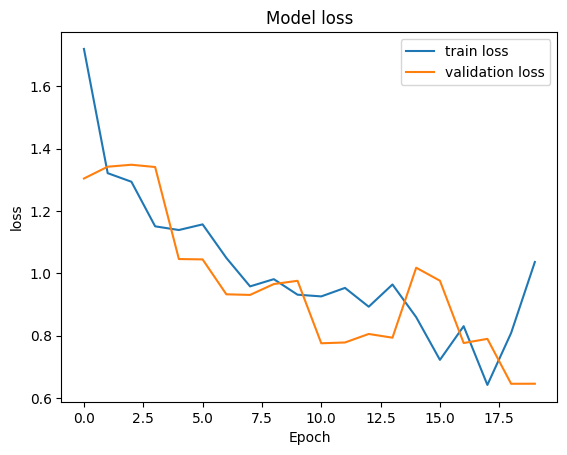

In [7]:

plt.plot(hoistory.history['loss'], label='train loss')
plt.plot(hoistory.history['val_loss'], label='validation loss')
plt.title('Model loss')
plt.xlabel('Epoch')
plt.ylabel('loss')
plt.legend()

plt.show()



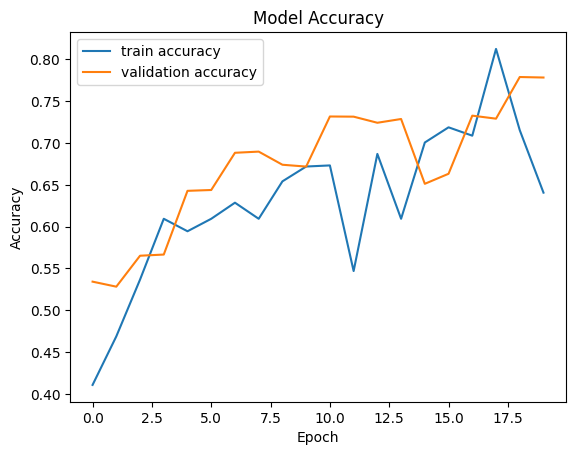

In [8]:
plt.plot(hoistory.history['accuracy'], label='train accuracy')
plt.plot(hoistory.history['val_accuracy'], label='validation accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()
